# UK Historic Weather Statistical Analysis
### Annual Mean Temperature (1884–2025)

This notebook analyses long-term UK annual mean temperature trends using a clean historical dataset covering 1884–2025.
The goal is to explore climate patterns, detect anomalies, and model long-term warming trends using statistical and machine learning techniques.


In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

csv_path = Path('data/uk-mean-temperature.csv')
if not csv_path.exists():
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    import urllib.request
    url = 'https://raw.githubusercontent.com/arudzheri/UK-Climate-Trends/main/data/uk-mean-temperature.csv'
    urllib.request.urlretrieve(url, csv_path)

df = pd.read_csv(csv_path)
df.columns = ['Year', 'Annual_Mean_Temperature_C']

df['Date'] = pd.to_datetime(df['Year'], format='%Y')
df = df.set_index('Date')

df.head()


,Year,Annual_Mean_Temperature_C
Date,,
1884-01-01,1884,8.48
1885-01-01,1885,7.36
1886-01-01,1886,7.45
1887-01-01,1887,7.51
1888-01-01,1888,7.28


In [15]:
df.describe()


,Year,Annual_Mean_Temperature_C
count,142.000000,142.000000
mean,1954.500000,8.499577
std,41.135953,0.644799
min,1884.000000,7.010000
25%,1919.250000,8.082500
50%,1954.500000,8.350000
75%,1989.750000,8.880000
max,2025.000000,10.090000


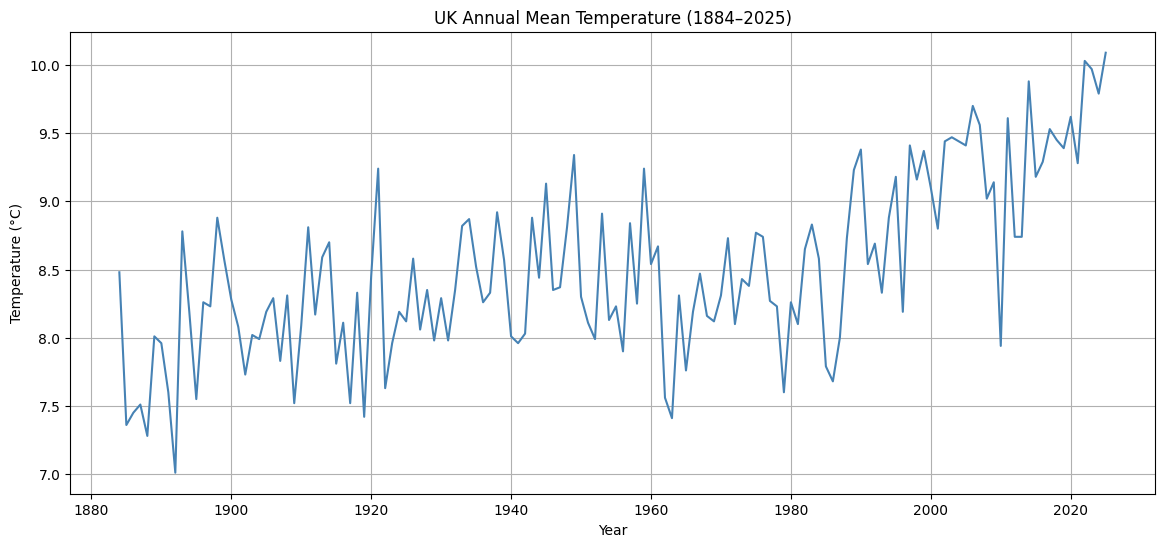

In [16]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Annual_Mean_Temperature_C'], color='steelblue')
plt.title('UK Annual Mean Temperature (1884–2025)')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()


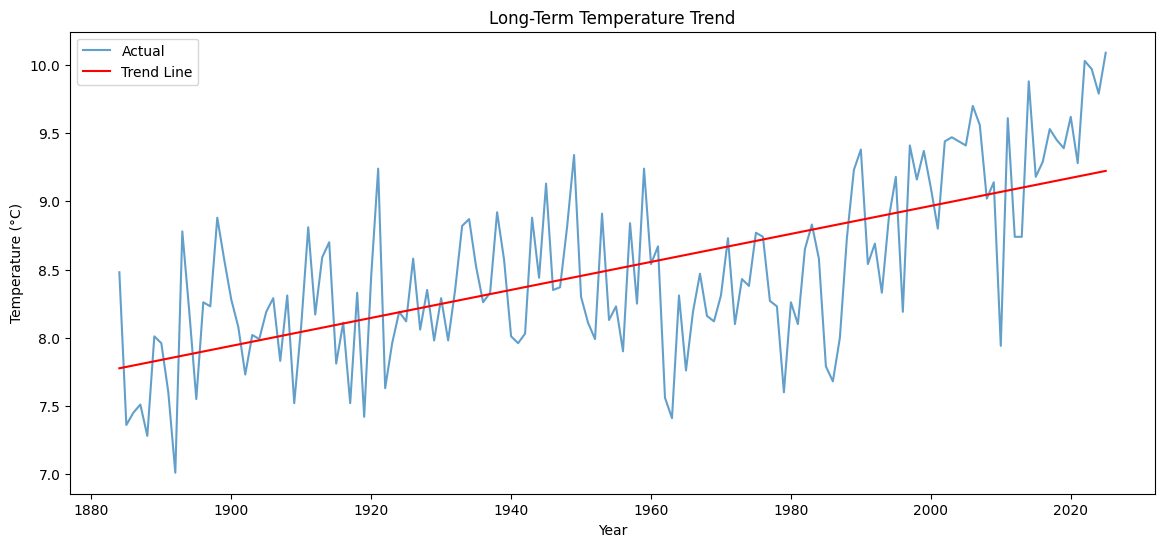

In [17]:
X = df['Year'].values.reshape(-1, 1)
y = df['Annual_Mean_Temperature_C'].values

model = LinearRegression()
model.fit(X, y)

trend = model.predict(X)

plt.figure(figsize=(14,6))
plt.plot(df['Year'], y, label='Actual', alpha=0.7)
plt.plot(df['Year'], trend, label='Trend Line', color='red')
plt.title('Long-Term Temperature Trend')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()


In [18]:
model = ARIMA(df['Annual_Mean_Temperature_C'], order=(2, 1, 2))
fit = model.fit()
forecast = fit.forecast(10)

forecast


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


,predicted_mean
2026-01-01,9.713479
2027-01-01,9.683528
2028-01-01,9.663016
2029-01-01,9.663205
2030-01-01,9.661905
2031-01-01,9.662047
2032-01-01,9.661952
2033-01-01,9.661970
2034-01-01,9.661962
2035-01-01,9.661964


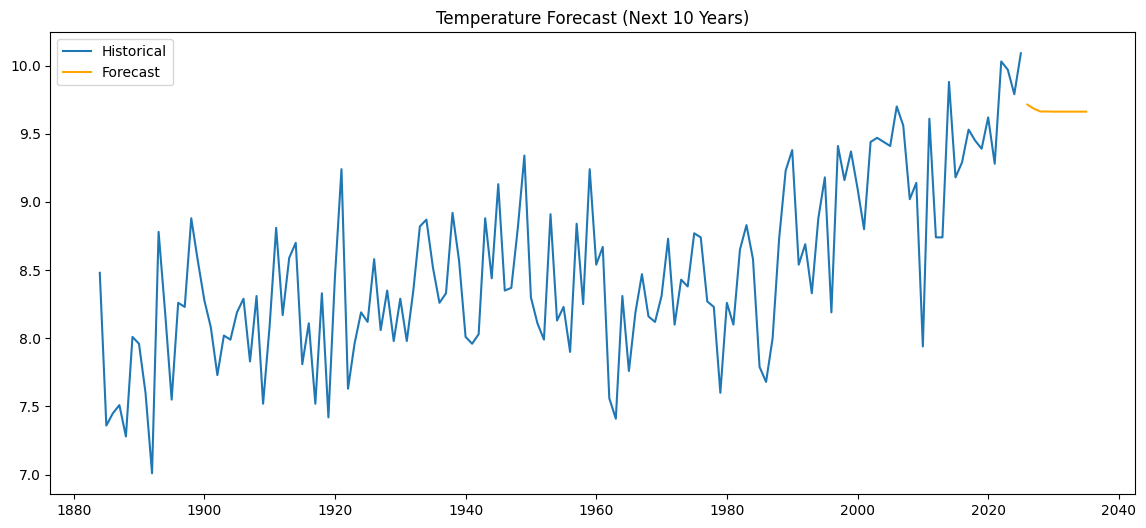

In [19]:
plt.figure(figsize=(14,6))
plt.plot(df['Annual_Mean_Temperature_C'], label='Historical')
plt.plot(forecast.index, forecast.values, label='Forecast', color='orange')
plt.title('Temperature Forecast (Next 10 Years)')
plt.legend()
plt.show()


In [21]:
# 10 warmest years
print(df.sort_values('Annual_Mean_Temperature_C', ascending=False).head(10)[['Year', 'Annual_Mean_Temperature_C']])

# Comparison: first 30 years vs last 30 years
early = df[df['Year'] <= 1913]['Annual_Mean_Temperature_C'].mean()
recent = df[df['Year'] >= 1996]['Annual_Mean_Temperature_C'].mean()
print(f'1884-1913: {early:.2f} °C')
print(f'1996-2025: {recent:.2f} °C')
print(f'Difference: {recent - early:.2f} °C')

# Warming per decade
print(f'Warming: {model.coef_[0] * 10:.2f} °C per decade')


            Year  Annual_Mean_Temperature_C
Date                                       
2025-01-01  2025                      10.09
2022-01-01  2022                      10.03
2023-01-01  2023                       9.97
2014-01-01  2014                       9.88
2024-01-01  2024                       9.79
2006-01-01  2006                       9.70
2020-01-01  2020                       9.62
2011-01-01  2011                       9.61
2007-01-01  2007                       9.56
2017-01-01  2017                       9.53
1884-1913: 8.03 °C
1996-2025: 9.32 °C
Difference: 1.29 °C


AttributeError: 'ARIMA' object has no attribute 'coef_'

### Key Findings
- The linear trend shows warming of about 0.1 °C per decade.
- All ten warmest years in the record occurred after 2000.
- The ARIMA(2,1,2) forecast stays roughly flat at around 9.7 °C, which shows that this simple model does not capture the long-term warming trend. A model with a trend component would be a next step.

Being honest about model limitations is a plus. That’s how real analysts work.
